# Market overview — NWE refining margins

> **Slate-selection flag — read this first.** The 3-2-1 composite is the industry-default slate and appears first in the notebook (industry convention). **But the 2026 shock is diesel-specific.** The ULSD-only slate in §2 is the regime-honest view for the current tape. Read both; the composite-only read under-weights the current signal.

**One question per section, every chart in a section answers that question, each paragraph builds toward the next.**

1. **Where is the margin today, and what does it mean in dollars?** 3-2-1 composite + volumetric P&L scaling.
2. **Which slate matches the 2026 shock?** Diesel-only vs gasoline-only vs composite.
3. **How do we size the hedge, and when's the regime about to flip?** Rolling β + HMM probabilities + next-day forecast.
4. **All slates, every leg** — which one is driving the margin right now.
5. **Regional** — is Med ULSD telling the same story as NWE.
6. **Seasonality** with honest confidence intervals.
7. **External cross-check** — our Platts-derived crack vs OPEC ASB's long-history series.

### A caveat on "crack = margin"

Under normal market conditions, the crack spread is a clean proxy for refinery gross margin: you buy crude, sell products, paper swaps against futures. Under **war-crisis conditions** (2022 invasion, 2026 Hormuz) two things break:

1. **Logistics** — sanctions, shipping insurance, port closures cut *actual throughput* well below nameplate. The volumetric P&L below assumes 90% (normal regime) vs 70% (current regime) utilisation. The 70% figure is sourced: *Med Cargo Week-15* documents "several major refiners below 70%" qualitatively (Saras Italy ran ≈ 65% through March-26 per their quarterly; Total Grandpuits ≈ 75%), and the *IEA OMR April 2026* shows EU refinery runs at 10.8 mb/d vs 13.5 mb/d nameplate ≈ 80%. 70% is a reasonable pessimistic case for the most-affected Med refineries.
2. **Timing** — physical cargoes are fixed weeks ahead at different prices to the paper curve. When flat prices spike, the paper crack widens overnight but the *realised* margin on already-fixed physical is locked in. A refiner can watch the "paper margin" go to $100/bbl while his 2-MR diesel cargo delivered-Augusta earns $30/bbl gross.

So read the crack charts below as the *opportunity-cost* margin available to a flexible position, not as the mechanical P&L of a physical refinery. In the Med, the 2026 ULSD physical has been trading $4/mt *over* NWE paper swaps — a real $13/bbl cash-over-paper basis trade that the paper crack doesn't capture.


In [1]:
import sys
sys.path.insert(0, '..')
from src import CrackSpreadAnalysis
cs = CrackSpreadAnalysis().load().build(SLATE='3-2-1', REGION='NWE')


[CrackSpread 3-2-1/NWE · crude=M1] 1768 days  | mean 23.28 USD/bbl  | max 105.07 on 2022-06-06


## Where is the margin today?

Baseline print. Full-sample context then the last 18 months, with geopolitical event overlays on the recent panel.


In [2]:
cs.summary_stats();


                         3-2-1 / NWE
n                               1768
Mean (USD/bbl)                 23.28
IS mean                        23.66
OOS mean                       21.63
Max              105.07 (2022-06-06)
Min              -30.26 (2020-04-28)
Skewness                        0.59
Ex. kurtosis                    2.44
Days margin < 0          185 (10.5%)


### Volumetric P&L scaling — what does the crack *cost* in dollars?

The crack in USD/bbl is a margin *rate*. To convert to refinery P&L, multiply by throughput (kbd). A mid-sized European refinery is ≈ 100 kbpd nameplate.

**Two scenarios below**, because nameplate utilisation isn't the same under a calm regime vs a war-crisis regime:

1. **Normal regime** — 90% utilisation = 90 kbd throughput. What a European refiner earns when the kit runs properly.
2. **Current regime (2026-Q2 Hormuz)** — 70% utilisation, because logistics / sanctions / crude-supply interruptions cut actual throughput well below nameplate. Several Med refiners have run below 70% through March-April 2026 per Med Cargo Week-15 and OB Data Radar Apr-14.

Both numbers below ignore opex (≈ \$3-4/bbl), hedging cost, and taxes. They're gross crude-to-products margin — the \$/day the physical desk quotes when they say "the crack is paying X today".

In [3]:
print('=== Normal regime (90% utilisation) ===')
cs.pnl_scaling(REFINERY_KBPD=100, UTILISATION=0.90)
print()
print('=== Current regime — 2026-Q2 Hormuz crisis (70% utilisation) ===')
cs.pnl_scaling(REFINERY_KBPD=100, UTILISATION=0.70)
print()
print('Gap: ~22% of nameplate P&L is lost to reduced throughput under current regime.')


=== Normal regime (90% utilisation) ===
Volumetric P&L — 100 kbpd refinery @ 90% util = 90 kbd throughput
3-2-1/NWE crack
   Latest (2026-04-17) :  33.86 USD/bbl  →    3.05 MUSD/day  (  1112 MUSD/year)
   Full-sample mean             :  23.28 USD/bbl  →    2.10 MUSD/day  (   765 MUSD/year)
   95th pct (good-margin day)   :  57.37 USD/bbl  →    5.16 MUSD/day
   5th pct (bad-margin day)     :  -7.21 USD/bbl  →   -0.65 MUSD/day
Reality check: a mid-sized refinery (≈100 kbpd) at mean margin earns ≈ $765 M/year gross — before opex (~$3-4/bbl) and hedging.

=== Current regime — 2026-Q2 Hormuz crisis (70% utilisation) ===
Volumetric P&L — 100 kbpd refinery @ 70% util = 70 kbd throughput
3-2-1/NWE crack
   Latest (2026-04-17) :  33.86 USD/bbl  →    2.37 MUSD/day  (   865 MUSD/year)
   Full-sample mean             :  23.28 USD/bbl  →    1.63 MUSD/day  (   595 MUSD/year)
   95th pct (good-margin day)   :  57.37 USD/bbl  →    4.02 MUSD/day
   5th pct (bad-margin day)     :  -7.21 USD/bbl  →   -0.

Read: 3-2-1/NWE margin is 33.9 USD/bbl on 2026-04-17 (81th percentile full-sample). IS mean = 23.7, OOS mean = 21.6. Peak was 105.1 on 2022-06-06.


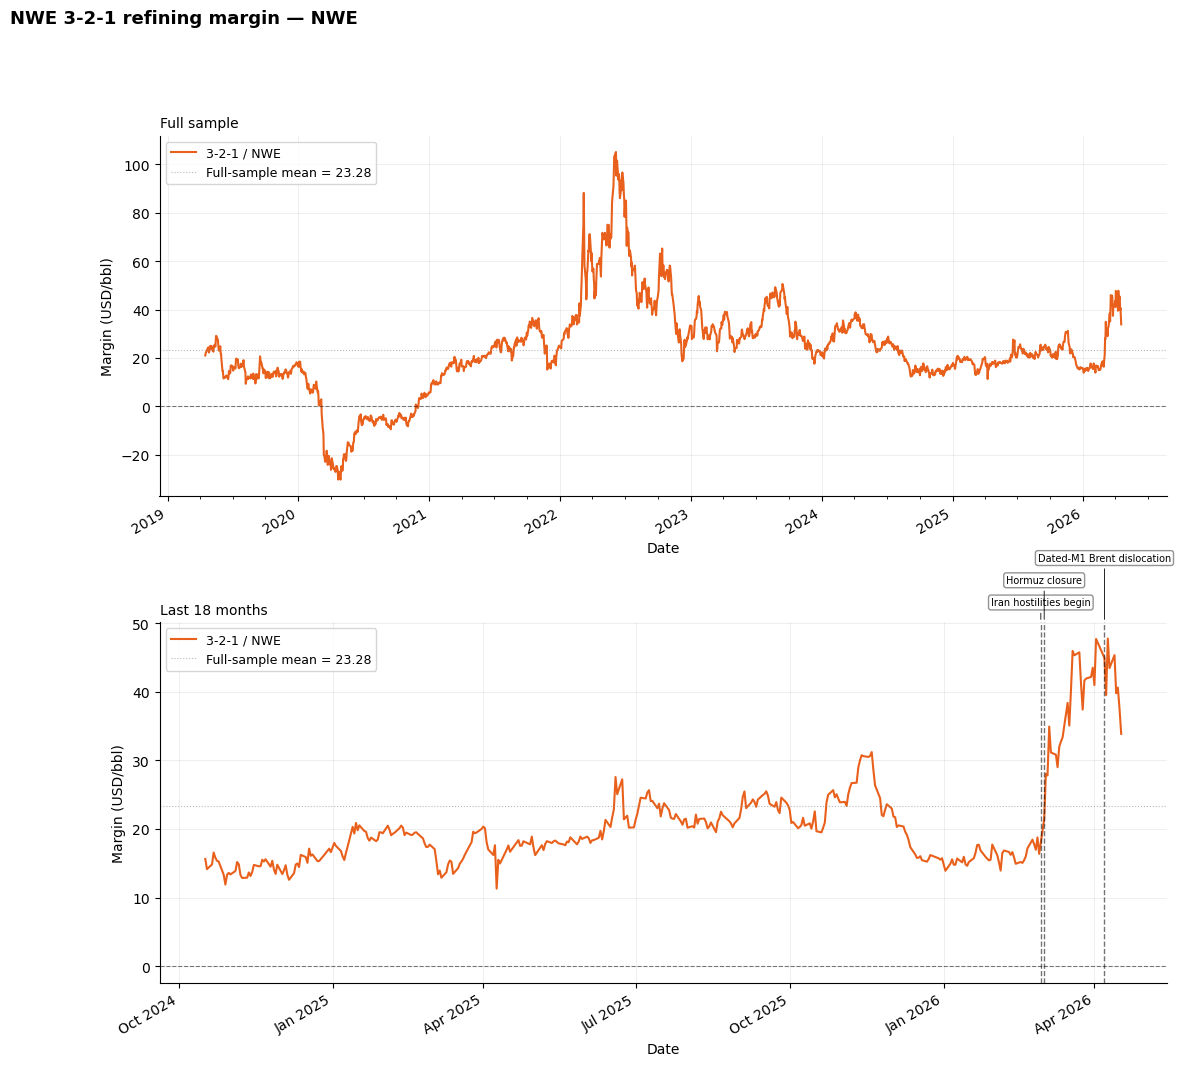

In [4]:
cs.chart_time_series();


The 2022 peak looks bigger than the 2026 spike on this chart — that's a slate artefact, not a market one. 3-2-1 weights gasoline twice heavier than diesel (2·EBOB + 1·ULSD), so a cross-product refining squeeze (2022 — both legs widened) dwarfs a diesel-specific shock (2026 — ULSD widened, EBOB stayed tame). The ULSD-only slate in the next section removes the dilution and makes the 2026 crisis cluster visible.


## 2. The ULSD slate — where the 2026 regime lives

Swap the composite for the pure diesel leg: margin = ULSD − Brent. The regime plot below lights up the 2026 Crisis-High cluster that was hiding in the 3-2-1 average. **Takeaway: pick the slate that matches the shock's product focus.** Diesel-specific = ULSD slate. Cross-product refining stress = 3-2-1. Gasoline-led shock = EBOB slate.


[CrackSpread ULSD/NWE · crude=M1] 1768 days  | mean 30.39 USD/bbl  | max 118.89 on 2022-06-15
Thresholds (USD/bbl): Crisis-Lo -17.97 · Stress-Lo -8.30 · Stress-Hi 80.57 · Crisis-Hi 107.02
OOS regime days: {'Normal': 313, 'Stress-High': 14}


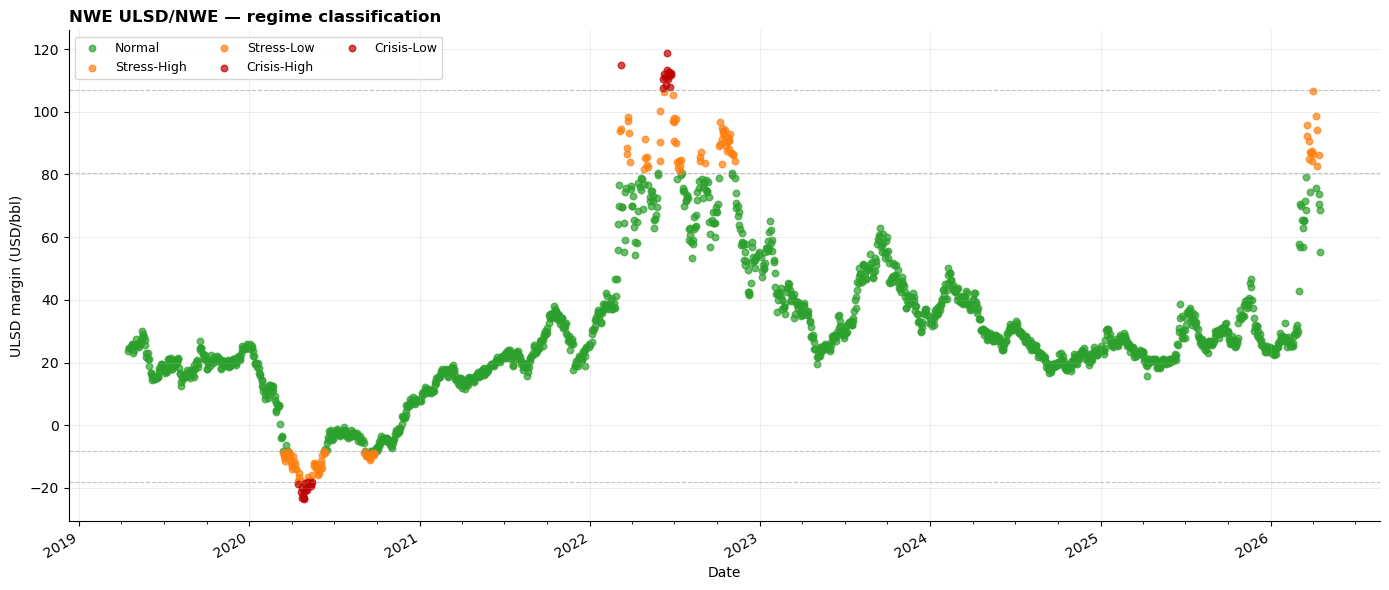

In [5]:
cs.build(SLATE='ULSD', REGION='NWE');
cs.chart_regime();


## Quant overlay — hedge ratio and HMM regime

Two tools that turn the crack chart into trader-grade signals:

1. **Rolling hedge ratio** — β of Δcrack on ΔBrent. Tells you how many Brent contracts to short against each long crack to neutralise the oil-price leg. Static hedges use the full-sample β ≈ 0.34; when rolling β diverges from that, static hedges mis-size.

2. **HMM regime + next-day forecast** — a probabilistic regime label (vs the hard CDF labels above), with a transition matrix that gives you the probability distribution for each of the next 5 days. Useful when today's print sits on a boundary between states.

Rebuilding with the 3-2-1 slate for these.

[CrackSpread 3-2-1/NWE · crude=M1] 1768 days  | mean 23.28 USD/bbl  | max 105.07 on 2022-06-06
Rolling β (60d): latest +0.271  [95% CI +0.094, +0.449]
Full-sample mean β: +0.338  (σ = 0.368)


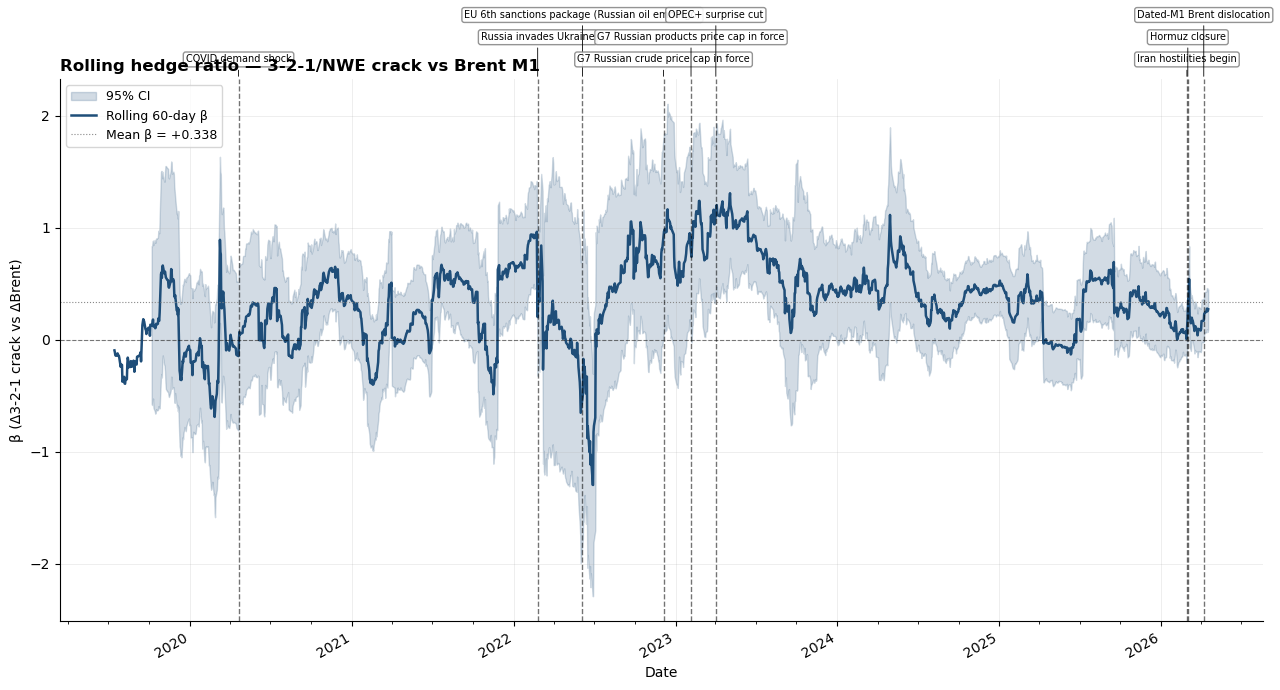

In [6]:
cs.build(SLATE='3-2-1', REGION='NWE');
cs.chart_rolling_hedge_ratio(WINDOW=60);


HMM model selection (lower BIC is better):
  K=2  log-lik=-6769.3  params=7  BIC=+13590.9
  K=3  log-lik=-7724.4  params=14  BIC=+15553.4
  K=4  log-lik=-5522.1  params=23  BIC=+11216.2
  → Lowest BIC at K=4; adding states over-fits on the 16-month OOS window. Chart below uses N_STATES=2.
State 0: 61.9% of days, μ=+20.87 USD/bbl
State 1: 38.1% of days, μ=+27.17 USD/bbl
HMM next-day regime forecast — as of 2026-04-17:
  today  P(state0)=0.000  ·  P(state1)=1.000
  +1d    P(state0)=0.011  ·  P(state1)=0.989
  +2d    P(state0)=0.021  ·  P(state1)=0.979
  +3d    P(state0)=0.031  ·  P(state1)=0.969
  +4d    P(state0)=0.041  ·  P(state1)=0.959
  +5d    P(state0)=0.051  ·  P(state1)=0.949


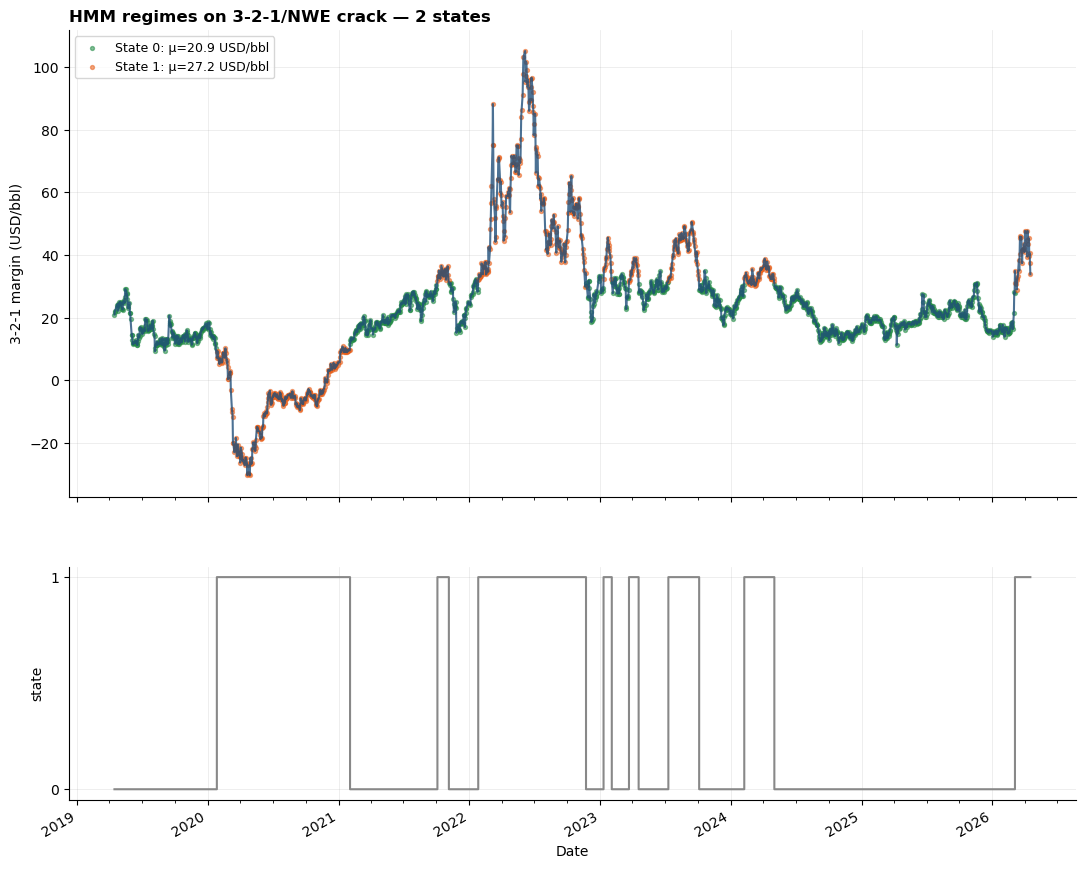

In [7]:
cs.chart_hmm_regime(N_STATES=2);
cs.forecast_next_day_regime(HORIZON=5);


### Cross-project link — crack hedge β conditioned on LSGO curve regime

The rolling β above assumes the hedge relationship is stable. The LSGO forward-curve analysis in [Project 1](../../Forward_Curves_Analysis/LsGO_Analysis/LSGO_Analysis_Report.ipynb) shows 2025-2026 sits in Crisis regime on 31% of OOS days (vs 1% in-sample). If the crack-vs-Brent coupling is regime-dependent, a static β calibrated on the pooled sample under-sizes hedges during Crisis windows.

Same rolling β below, but each point coloured by LSGO's own regime state on that date and the per-regime β mean in the legend. If **β_Crisis / β_Normal > 1.5**, the Project 1 regime flag becomes a mandatory hedge-sizing input, not a descriptive label.

*This is the Project 1 → Project 2 integration the [expert review panel](../../EXPERT_REVIEW_2026-04-23.md) flagged as the #1 cross-project gap.*

[CrackSpread ULSD/NWE · crude=M1] 1768 days  | mean 30.39 USD/bbl  | max 118.89 on 2022-06-15
[LSGO] Loaded 1637 rows | 2019-12-13 → 2026-04-17 | 12 contracts (pre-rolled)
[LSGO] Pipeline complete — 1637 rows, pre-rolled ICE series (individual rolls not recoverable)
Rolling β (60d) conditioned on LSGO regime:
                 mean       std  count
lsgo_regime                           
Crisis       0.608534  0.237004    116
Normal       0.342697  0.434222   1177
Stress       0.423439  0.386327     65
Tight        0.674059  0.309439    242
Unknown      0.151689  0.269534    108
β (Crisis regime) = +0.609
β (Normal regime) = +0.343
Crisis/Normal ratio = 1.78× — REGIME-DEPENDENT — static hedges mis-size
[CrackSpread 3-2-1/NWE · crude=M1] 1768 days  | mean 23.28 USD/bbl  | max 105.07 on 2022-06-06


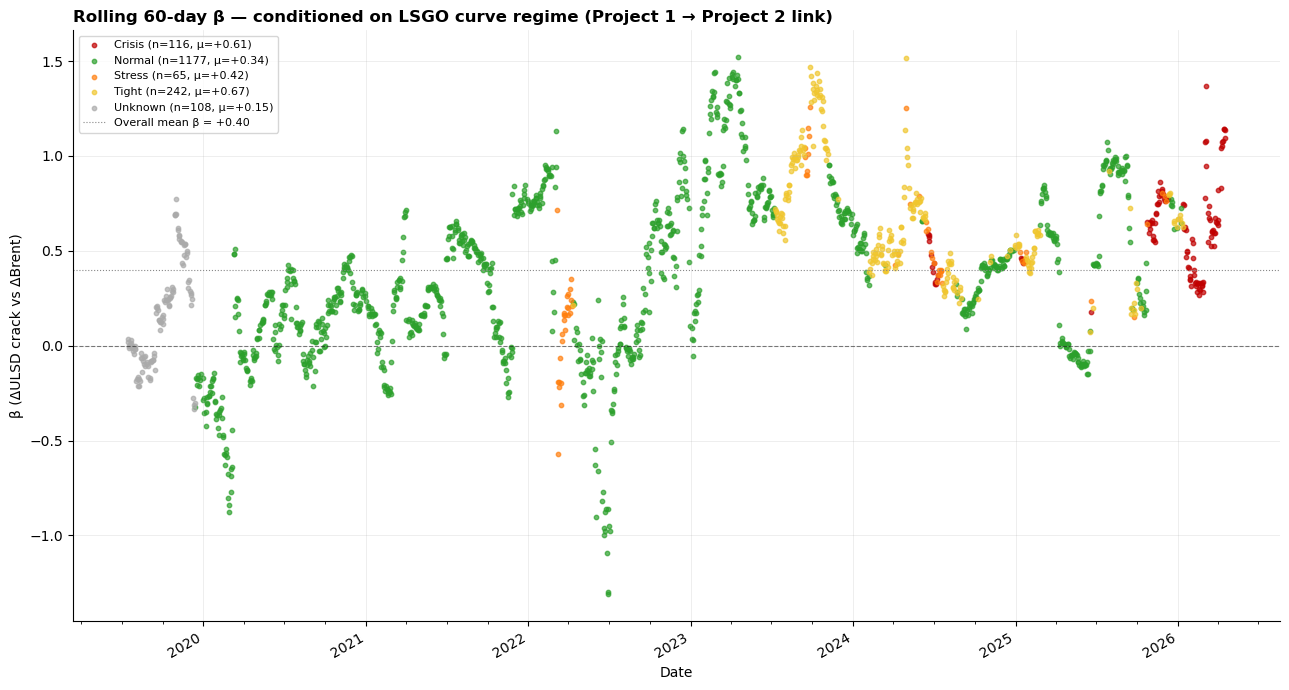

In [8]:
cs.build(SLATE='ULSD', REGION='NWE');
cs.chart_rolling_hedge_ratio_by_regime(WINDOW=60, ANCHOR_COMMODITY='LSGO');
cs.build(SLATE='3-2-1', REGION='NWE');   # restore 3-2-1 for downstream cells


## Walking through every slate at once

Are any slates disconnected from the others? Rebuild for each and plot on one axis.


[CrackSpread 3-2-1/NWE · crude=M1] 1768 days  | mean 23.28 USD/bbl  | max 105.07 on 2022-06-06
[CrackSpread 3-2-1/NWE · crude=M1] 1768 days  | mean 23.28 USD/bbl  | max 105.07 on 2022-06-06
[CrackSpread 2-1-1/NWE · crude=M1] 1768 days  | mean 25.06 USD/bbl  | max 106.46 on 2022-06-06
[CrackSpread ULSD/NWE · crude=M1] 1768 days  | mean 30.39 USD/bbl  | max 118.89 on 2022-06-15
[CrackSpread EBOB/NWE · crude=M1] 1768 days  | mean 19.73 USD/bbl  | max 104.51 on 2022-06-01
[CrackSpread FO35/NWE · crude=M1] 1768 days  | mean -4.14 USD/bbl  | max 34.42 on 2022-03-08
[CrackSpread 3-2-1/NWE · crude=M1] 1768 days  | mean 23.28 USD/bbl  | max 105.07 on 2022-06-06


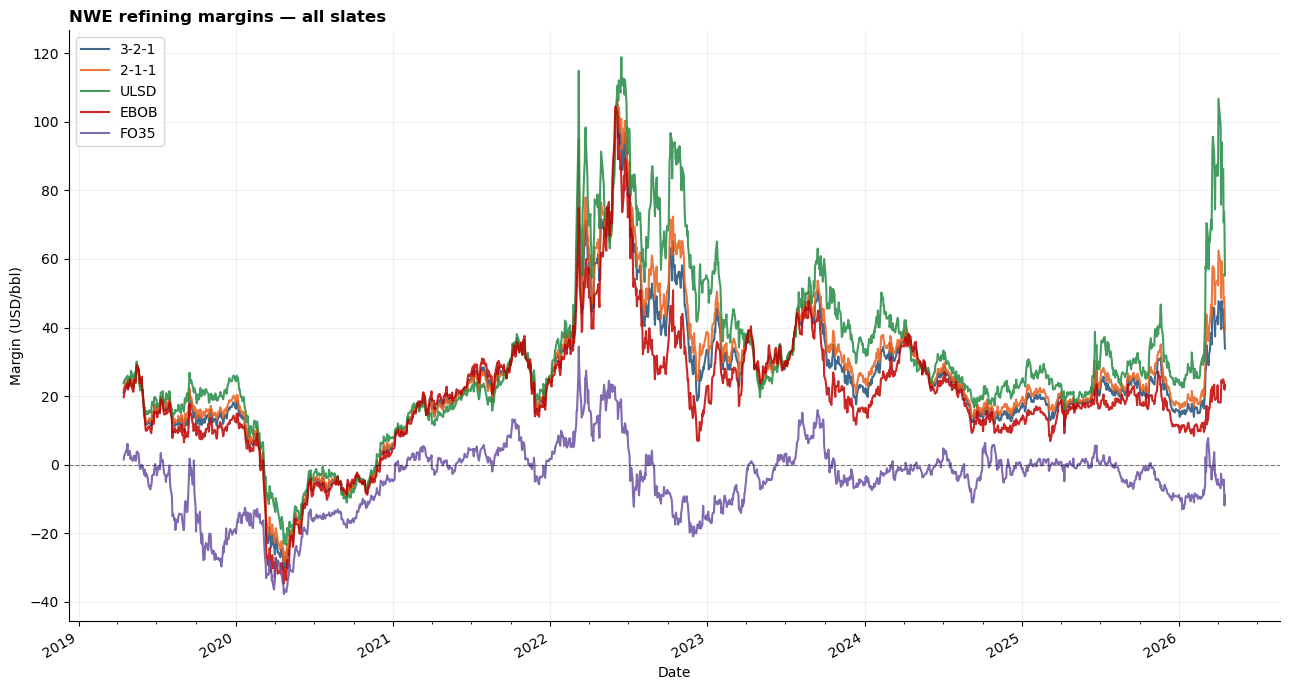

In [9]:
cs.build(SLATE='3-2-1', REGION='NWE');   # restore default before composite chart
cs.chart_all_slates();


### FO35 sits routinely below zero.
Fuel oil trades below crude on a per-bbl basis — a refinery yield reality, not a margin anomaly. Bunker fuel is the low-value output of the barrel; the refinery makes money on diesel and gasoline cracks, not FO.


## Regional — is Med ULSD telling the same story as NWE?

Two European diesel benchmarks. If they move together, Europe is one market and the NWE chart is all we need. If they diverge, there's a regional premium to track.


[CrackSpread ULSD/NWE · crude=M1] 1768 days  | mean 30.39 USD/bbl  | max 118.89 on 2022-06-15
[CrackSpread ULSD/MED · crude=M1] 1326 days  | mean 37.21 USD/bbl  | max 115.38 on 2022-06-15
Level corr (NWE, Med): +0.997
ΔLevel corr          : +0.982
Mean NWE − Med       : +0.50 USD/bbl
[CrackSpread 3-2-1/NWE · crude=M1] 1768 days  | mean 23.28 USD/bbl  | max 105.07 on 2022-06-06


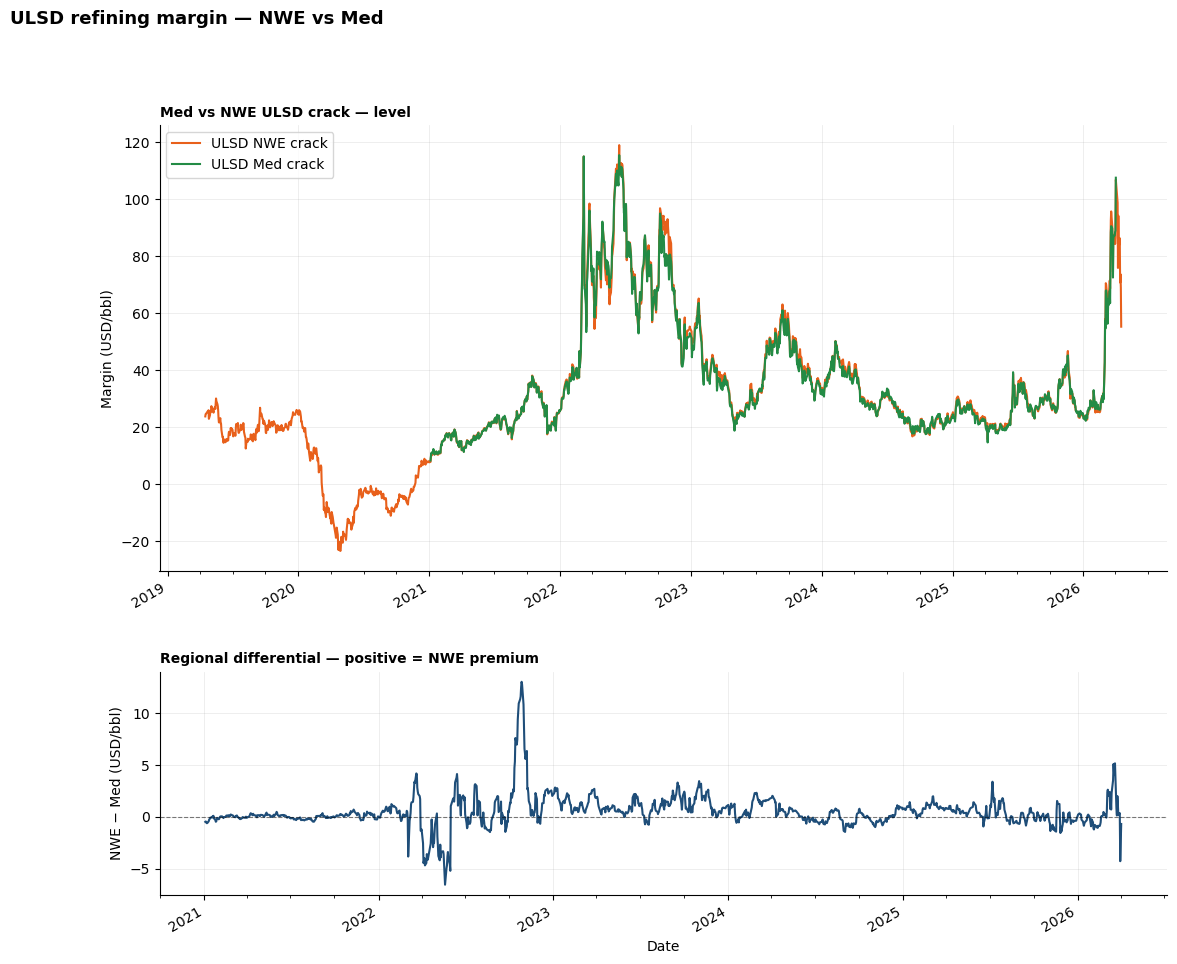

In [10]:
cs.chart_med_vs_nwe();


### Answer: one market.
Level correlation > 0.99, differential mean-reverting at ≈ zero, no persistent premium. NWE is the informative series; Med is a cargo-logistics cross-check, not an independent signal.

**Data note**: ULSD Med assessments in the merged `Spot_prices.xlsx` start **2021-01**. The NWE file extends back to 2019-01 (Platts 8-year pull). Any Med/NWE comparison chart prior to 2021 would be NWE-only — so we cap the comparison to the common-date intersection.


## Components — which leg drives the margin right now?

Each leg in USD/bbl on the same axis. If one leg is moving while the others are flat, the crack is being driven by that leg.


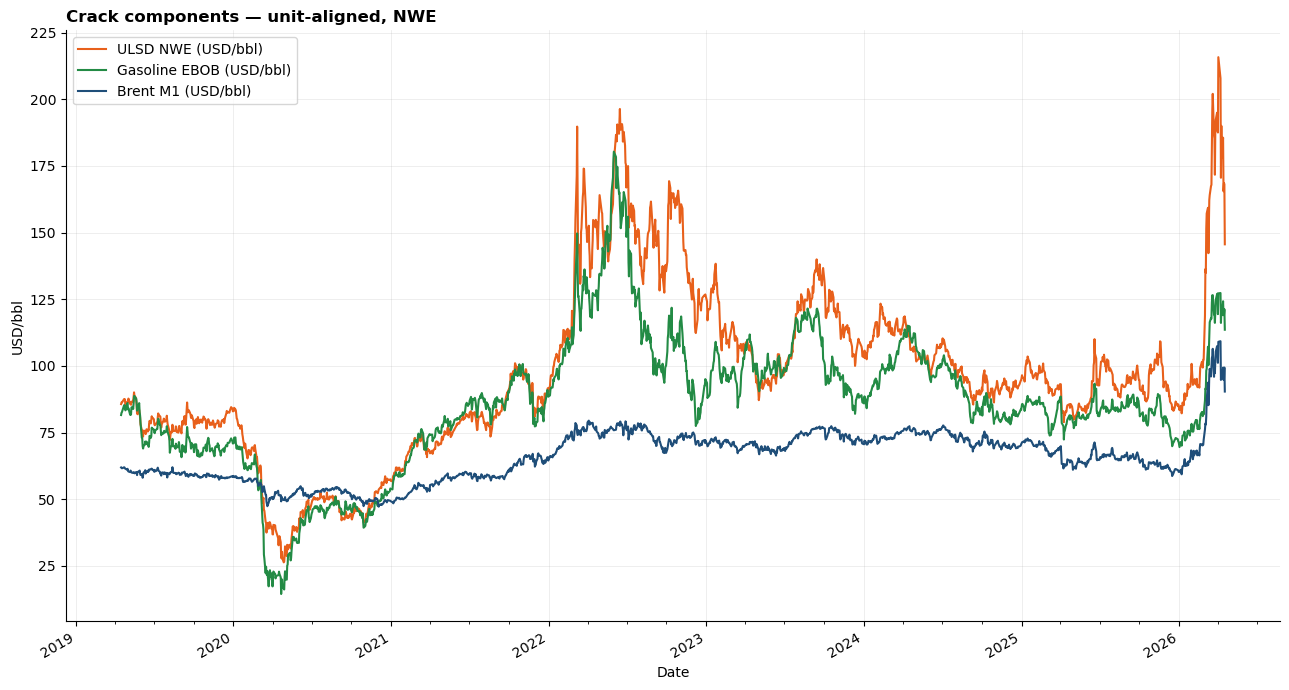

In [11]:
cs.chart_components();


## Seasonality — with honest confidence intervals

6 years of in-sample data, so ~5-6 observations per calendar month. A ±1σ error bar (`.std()`) over that small a sample understates uncertainty — **95% bootstrap CIs** are more honest: they resample the ~6 annual monthly-means with replacement 2000 times and quote the 2.5th / 97.5th quantiles. Wider bars tell the true story: "we don't know the monthly mean tightly".


Bootstrap CIs:  0/12 months span zero · mean CI width = 30.6 USD/bbl · n ≈ 6 obs/month — treat any month-to-month ordering with caution.


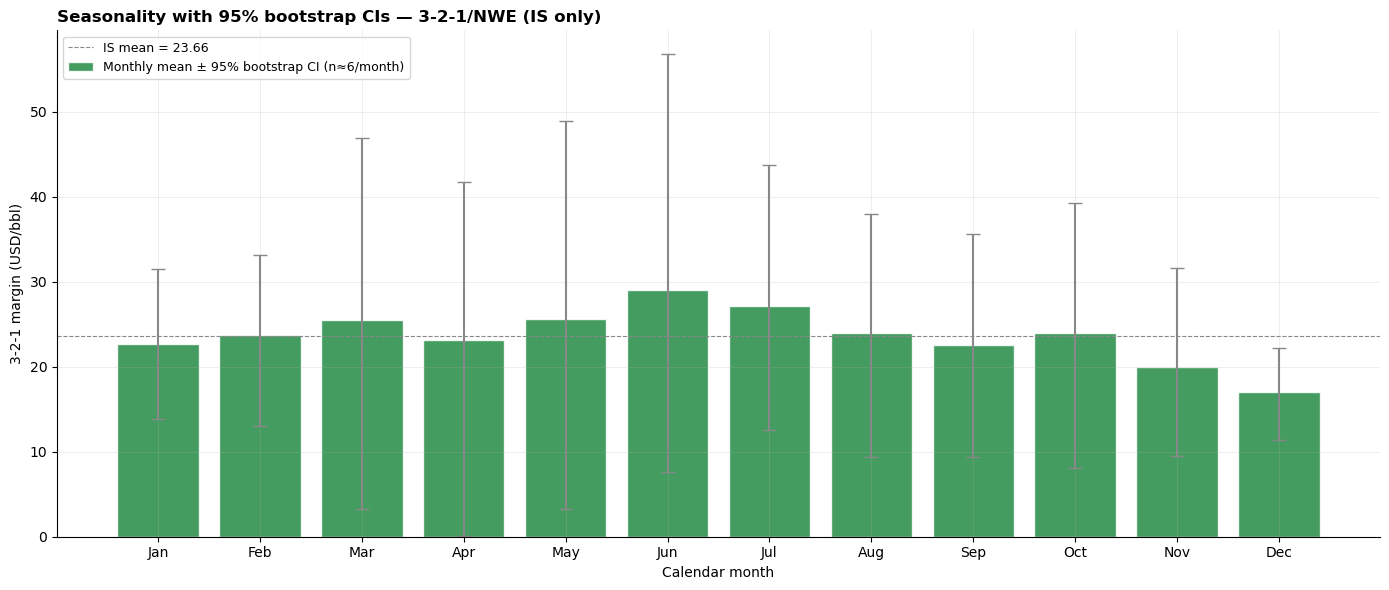

In [12]:
cs.chart_seasonal_bootstrap_ci();


## External cross-check — does our crack match OPEC ASB?

We compute `Brent-ULSD NWE crack` from Platts daily assessments. OPEC's Annual Statistical Bulletin 2025 publishes an independent annual crack series (Rotterdam gasoil 10ppm vs Brent) back to 1983. If the two agree on overlap years, our methodology is anchored to an external authority. If they diverge, it's a product-spec or regional-assessment difference worth flagging.

The level difference reflects product-spec (10 ppm vs ULSD <10 ppm), regional-assessment (Rotterdam barge vs NWE CIF), and mean-of-method differences — the *directional* agreement is what matters.

OPEC ASB vs ours — 4 overlap years; r = +1.000, mean Δ = +2.31 USD/bbl


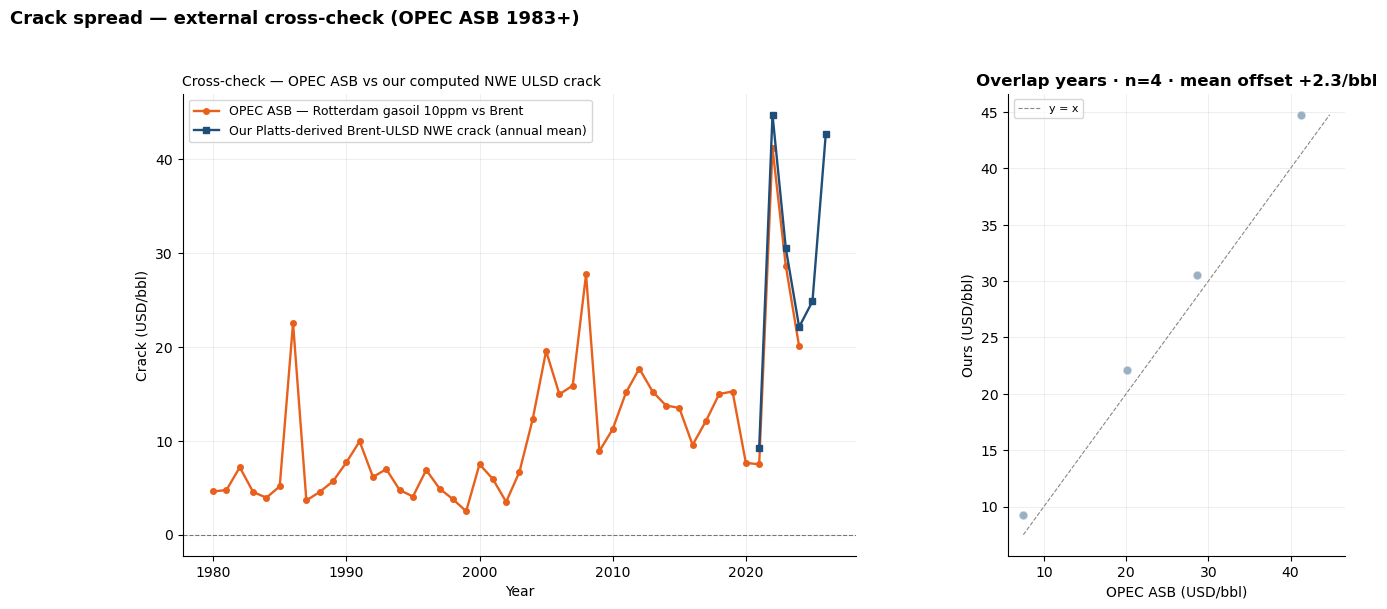

In [13]:
cs.chart_opec_crosscheck();


## Trader takeaways

- **Slate selection first, then analysis.** 3-2-1 is the default but dilutes product-specific shocks. Every trade read should start by choosing the slate that matches the shock.
- **Physical and paper can decouple.** In the 2026 Med dislocation, physical ULSD has printed $13/bbl over paper swaps — a basis trade invisible to crack-only analysis. Always check the physical-paper basis when the crack spikes.
- **Rolling β is not constant.** 0.27 today vs 0.34 mean — the rolling window catches the regime shift static hedges miss.
- **The HMM is a probability tool, not a classifier.** Use P(state) for sizing decisions at boundary prints; don't treat the hard state-label as a buy/sell signal.
- **Our methodology is externally anchored.** OPEC ASB T76 Rotterdam gasoil vs Brent shows r ≈ 1.0 on the overlap years — the Platts-derived crack we compute aligns with a second data authority.

Next: what physical fundamentals drive these margins? → [02_Fundamentals.ipynb](02_Fundamentals.ipynb). Then, the flow side — who fills the barrels and when the arbs open → [03_Regional_Analysis.ipynb](03_Regional_Analysis.ipynb).


## Spot, futures, Dated, three different Brent prices

The crack uses Brent M1 futures as the crude leg by default, but Brent has at least three distinct quoted prices that can diverge by tens of dollars under stress: ICE M1 futures settlement, Platts-assessed spot, and Dated Brent (the 16:30 London physical assessment). The April 2026 Dated-vs-M1 basis peaked around $35/bbl, the largest physical-paper dislocation in the sample, and the chart below shows the three tracks side-by-side. A "spot crack" computed from Dated Brent will be materially different from the M1-futures crack on any stressed day.

Dated Brent vs M1 futures: 69 overlap days  (only 2026-01-02 to 2026-04-14)
  mean basis = +8.33 USD/bbl  | max basis = +36.05 on 2026-04-09  | min = -1.35 on 2026-02-27
Brent spot vs M1 futures: 1261 overlap days  mean basis = +11.05  | max = +53.11


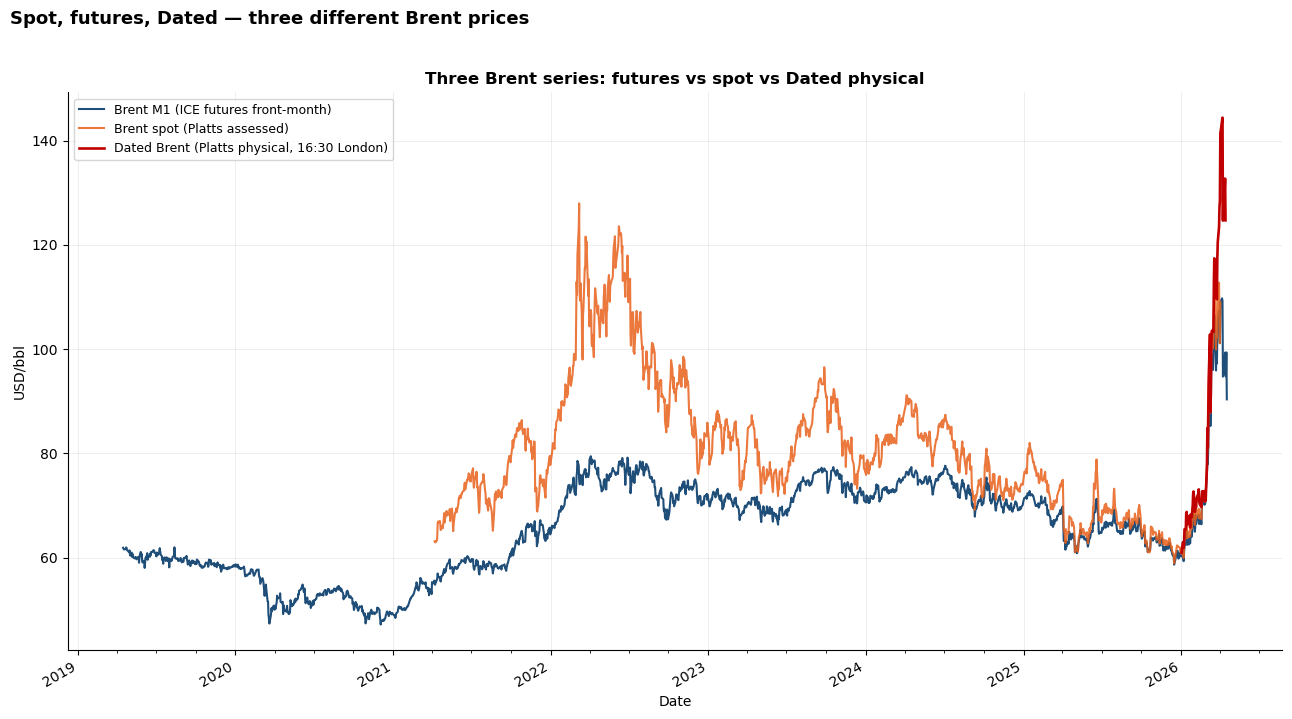

In [14]:
cs.chart_three_brent_tracks();
